In [1]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
#from osgeo import gdal, osr, gdalconst, gdal_array

In [2]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=3, g=14, r=29):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    ax.axis("off")
    im = ax.imshow(img)  # 画像を表示
    plt.show()

# 指定した座標 (x, y) でのスペクトルデータを表示するための関数
def show_spectral(img, param, y, x): 
    fig, ax = plt.subplots()  # fig と ax を定義
    ax.plot(param[ 0: 58,0], img[y, x,  0: 58], label="VNIR Spectrum", color="r");
    ax.plot(param[58:185,0], img[y, x, 58:185], label="SWIR Spectrum", color="g");
    ax.tick_params(labelsize=16)
    ax.legend();    plt.tight_layout(); plt.show()

#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

In [2]:

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
# 実行環境に合わせて E:\... の部分を修正してください。
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# HISUI画像処理・読み込み関数群 (省略なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    # Ensure not reading beyond available rows/columns
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            # Check if column index (j+1) exists in the CSV
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan # Or 0.0, indicate missing data
                # print(f"Warning: Column {j+1} missing in {fileb} at row {i}")
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            # Read all lines, split if '=' exists, ignore lines without '='
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line] # Split only once
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                # Attempt to convert to float, otherwise keep as string
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str # Keep potentially important string values

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    # Check if all required keys exist and are convertible to float
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")

    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    # Input validation
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")

    im = np.ones(img.shape[:2], dtype=np.uint8) # Use uint8 for mask for efficiency
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        # print(f"Warning: Band index {no_data_band_index} for no-data mask out of bounds. Using index 0.")
        im[img[:,:,0] == 0] = 0

    img_float = img.astype(float)
    # Apply radiometric vnir (bands 0-57)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    # Apply radiometric swir (bands 58-184)
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    # Apply mask after calculations
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float) # Ensure float type
    # Use .copy() to avoid potential views if img bands are needed elsewhere
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B

    # Normalize robustly: handle all-zero or constant-value images
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9: # Avoid division by zero or near-zero
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9: # Handle constant non-zero image (normalize to 1.0)
       ims.fill(1.0)
    else: # Handle all-zero image (remains 0.0)
       ims.fill(0.0)

    # Clipping might be redundant after robust normalization but harmless
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")

    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    # Check if wave and rad have the same length
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    # Return directly as NumPy array, avoid intermediate list
    return np.column_stack((wave, rad)) # Shape: (num_swir_bands, 2)


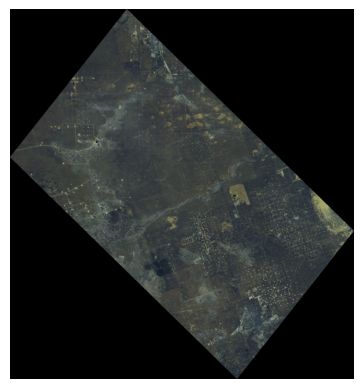

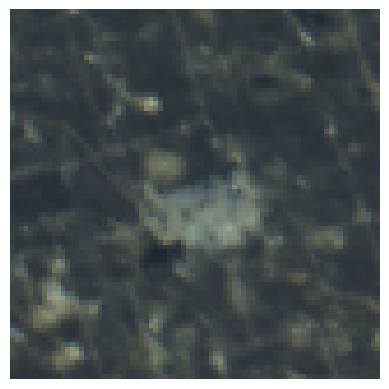

In [3]:
file = (r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.tif")
img = tifffile.imread(file) # read tif file
param = read_bfile(file)    # read radiometric file (..._B.csv)
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)  # read meta file (....txt)
img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)  # apply radiometric parameter
ims = get_rgb(img, b=8, g=18, r=28)
center = np.array([1065, 1463]) #中心座標(y, x), ここを変える
#ここで切り取りの範囲を設定
img_slice = img[center[0] - 40 : center[0] + 40, center[1] -40 : center[1] + 40, :] #補正後の画像
ims_slice = ims[center[0] - 40 : center[0] + 40, center[1] -40 : center[1] + 40, :] #画像表示用の画像
show_img(ims)
show_img(ims_slice)

In [6]:
# =========================================================
# Example Usage (主要部分のみ)

current_dir = os.getcwd()
print(f"=========================================================")
print(f"現在の作業フォルダ (ここに 'estimated_ch4_map.png' が保存されます):")
print(f"{current_dir}")
print(f"=========================================================")
    # --- ★ここまで追加 ---


現在の作業フォルダ (ここに 'estimated_ch4_map.png' が保存されます):
e:\tools


In [9]:
import cv2
import numpy as np

# --- ここに 'ims' (float型) が定義されていると仮定 ---
# (ims = get_rgb(...) の結果)

# 描画用にコピー (元のデータを壊さないため)
image_to_draw = ims.copy()

# === 手動で 0-255 の uint8 に正規化 ===
min_val = np.min(image_to_draw)
max_val = np.max(image_to_draw)

print(f"元のデータ型: {image_to_draw.dtype}")
print(f"元の値の範囲: {min_val} 〜 {max_val}")

if max_val == min_val:
    ims_normalized_uint8 = np.zeros(image_to_draw.shape, dtype=np.uint8)
else:
    image_to_draw = (image_to_draw - min_val) / (max_val - min_val)
    ims_normalized_uint8 = (image_to_draw * 255.0).astype(np.uint8)

print(f"正規化後のデータ型: {ims_normalized_uint8.dtype}")

# === 色の順序 (RGB -> BGR) の変換 ===
# 'get_rgb' は RGB 順と仮定し、OpenCV 用の BGR 順に変換
if len(ims_normalized_uint8.shape) == 3 and ims_normalized_uint8.shape[2] == 3:
    print("RGB から BGR に色順序を変換します。")
    ims_bgr_uint8 = cv2.cvtColor(ims_normalized_uint8, cv2.COLOR_RGB2BGR)
else:
    ims_bgr_uint8 = ims_normalized_uint8


# === スケールバーの計算 (10km) ===
one_pixel_meter = 20.0
scale_bar_meters = 10000
scale_bar_pixels = int(scale_bar_meters / one_pixel_meter) # 500 ピクセル

# === スケールバーの描画 ===
(h, w) = ims_bgr_uint8.shape[:2]
margin_px = 50
bar_thickness = 5
text_font_scale = 1.0
text_thickness = 2

bar_x_start = margin_px
bar_y_start = h - margin_px
bar_x_end = bar_x_start + scale_bar_pixels
bar_y_end = bar_y_start + bar_thickness

text_x = bar_x_start
text_y = bar_y_start - 10

# 描画色 (白: BGR)
scale_color = (255, 255, 255) 

cv2.rectangle(ims_bgr_uint8, (bar_x_start, bar_y_start), (bar_x_end, bar_y_end), scale_color, -1)
cv2.putText(ims_bgr_uint8, "10 km", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 
            text_font_scale, scale_color, text_thickness, lineType=cv2.LINE_AA)

# === 四角形の描画 ===
# 四角形の色 (黄色: BGR)
rect_color = (0, 255, 255) # B=0, G=255, R=255
rect_thickness = 2 # 線の太さ

# --- ご指定の四角 ---
center = np.array([1065, 1463]) # (y, x)
half_size = 40
# OpenCVの座標 (x, y) に注意
pt1 = (center[1] - half_size, center[0] - half_size) # (x1, y1) = (1423, 1025)
pt2 = (center[1] + half_size, center[0] + half_size) # (x2, y2) = (1503, 1105)
cv2.rectangle(ims_bgr_uint8, pt1, pt2, rect_color, rect_thickness)
print(f"四角形を {pt1} から {pt2} に描画しました。")


# === 画像の保存 ===
output_filename = "image_with_scale_and_main_rect.png"
cv2.imwrite(output_filename, ims_bgr_uint8)

print(f"正規化し、縮尺と四角形を描画した画像を '{output_filename}' として保存しました。")

元のデータ型: float64
元の値の範囲: 0.0 〜 1.0
正規化後のデータ型: uint8
RGB から BGR に色順序を変換します。
四角形を (np.int64(1423), np.int64(1025)) から (np.int64(1503), np.int64(1105)) に描画しました。
正規化し、縮尺と四角形を描画した画像を 'image_with_scale_and_main_rect.png' として保存しました。


In [ ]:
# 縮尺
import cv2
import numpy as np

# --- ここに 'ims' (float型) が定義されていると仮定 ---
# (ims = get_rgb(...) の結果)

# 描画用にコピー (元のデータを壊さないため)
image_to_draw = ims.copy()

# === 手動で 0-255 の uint8 に正規化 ===
# 1. データの最小値と最大値を取得
min_val = np.min(image_to_draw)
max_val = np.max(image_to_draw)

print(f"元のデータ型: {image_to_draw.dtype}")
print(f"元の値の範囲: {min_val} 〜 {max_val}")

# ゼロ除算を避ける (画像が真っ黒で min == max の場合)
if max_val == min_val:
    # 全て同じ値なので、すべて0 (黒) の uint8 画像にする
    ims_normalized_uint8 = np.zeros(image_to_draw.shape, dtype=np.uint8)
else:
    # 2. (値 - 最小値) / (最大値 - 最小値) で 0.0-1.0 の範囲にスケーリング
    image_to_draw = (image_to_draw - min_val) / (max_val - min_val)
    
    # 3. 255を掛けて 0-255 の範囲にし、uint8 型に変換
    ims_normalized_uint8 = (image_to_draw * 255.0).astype(np.uint8)

print(f"正規化後のデータ型: {ims_normalized_uint8.dtype}")
print(f"正規化後の値の範囲 (確認): {np.min(ims_normalized_uint8)} 〜 {np.max(ims_normalized_uint8)}")

# === 色の順序 (RGB -> BGR) の確認 ===
# 'get_rgb' という関数名から、'ims' は (R, G, B) の順である可能性が高いです。
# OpenCV (cv2) は (B, G, R) の順序を期待するため、変換が必要です。
# もし変換しないと、赤と青が入れ替わった画像が保存されます。

# チャンネル数が3の場合のみ変換
if len(ims_normalized_uint8.shape) == 3 and ims_normalized_uint8.shape[2] == 3:
    print("RGB から BGR に色順序を変換します。")
    ims_bgr_uint8 = cv2.cvtColor(ims_normalized_uint8, cv2.COLOR_RGB2BGR)
else:
    # グレースケールや既にBGRの場合 (確実ではないが)
    ims_bgr_uint8 = ims_normalized_uint8


# === スケールバーの計算 (10km) ===
one_pixel_meter = 20.0
scale_bar_meters = 10000
scale_bar_pixels = int(scale_bar_meters / one_pixel_meter) # 500 ピクセル

# === スケールバーの描画 ===
(h, w) = ims_bgr_uint8.shape[:2]
margin_px = 50
bar_thickness = 5
text_font_scale = 1.0
text_thickness = 2

bar_x_start = margin_px
bar_y_start = h - margin_px
bar_x_end = bar_x_start + scale_bar_pixels
bar_y_end = bar_y_start + bar_thickness

text_x = bar_x_start
text_y = bar_y_start - 10

# 描画色 (白) - (B, G, R) 順
color = (255, 255, 255) 

# BGRに変換された uint8 画像に描画
cv2.rectangle(ims_bgr_uint8, (bar_x_start, bar_y_start), (bar_x_end, bar_y_end), color, -1)
cv2.putText(ims_bgr_uint8, "10 km", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 
            text_font_scale, color, text_thickness, lineType=cv2.LINE_AA)

# === 画像の保存 ===
output_filename = "image_with_scale_bar_normalized_manual.png"
cv2.imwrite(output_filename, ims_bgr_uint8)

print(f"正規化し、スケールバーを描画した画像を '{output_filename}' として保存しました。")


元のデータ型: float64
元の値の範囲: 0.0 〜 1.0
正規化後のデータ型: uint8
正規化後の値の範囲 (確認): 0 〜 255
RGB から BGR に色順序を変換します。
正規化し、スケールバーを描画した画像を 'image_with_scale_bar_normalized_manual.png' として保存しました。


In [7]:
import cv2
import numpy as np

# --- ここに 'ims_slice' (float型) が定義されていると仮定 ---
# (ims_slice = ims[center[0] - 40 : center[0] + 40, ...])

# 描画用にコピー
image_to_draw = ims_slice.copy()

# === 手動で 0-255 の uint8 に正規化 ===
min_val = np.min(image_to_draw)
max_val = np.max(image_to_draw)

print(f"元のデータ型 (ims_slice): {image_to_draw.dtype}")
print(f"元の値の範囲 (ims_slice): {min_val} 〜 {max_val}")

if max_val == min_val:
    ims_normalized_uint8 = np.zeros(image_to_draw.shape, dtype=np.uint8)
else:
    # 0.0-1.0 の範囲にスケーリング
    image_to_draw = (image_to_draw - min_val) / (max_val - min_val)
    # 0-255 の範囲にし、uint8 型に変換
    ims_normalized_uint8 = (image_to_draw * 255.0).astype(np.uint8)

print(f"正規化後のデータ型: {ims_normalized_uint8.dtype}")

# === 色の順序 (RGB -> BGR) の変換 ===
# 'get_rgb' で作成された 'ims' から切り出しているため、
# 'ims_slice' も RGB 順であると仮定し、OpenCV 用の BGR 順に変換します。
if len(ims_normalized_uint8.shape) == 3 and ims_normalized_uint8.shape[2] == 3:
    print("RGB から BGR に色順序を変換します。")
    ims_bgr_uint8 = cv2.cvtColor(ims_normalized_uint8, cv2.COLOR_RGB2BGR)
else:
    ims_bgr_uint8 = ims_normalized_uint8

# === スケールバーの計算 (1km) ===
one_pixel_meter = 20.0
scale_bar_meters = 1000  # 1km = 1000 メートル
scale_bar_pixels = int(scale_bar_meters / one_pixel_meter) # 50 ピクセル

# === スケールバーの描画 (80x80画像用に調整) ===
(h, w) = ims_bgr_uint8.shape[:2]

margin_px = 10      # 画像の端からの余白 (ピクセル)
bar_thickness = 2   # スケールバーの太さ (ピクセル)
text_font_scale = 0.5 # テキストの大きさ
text_thickness = 1  # テキストの太さ

# スケールバーの座標 (左下)
bar_x_start = margin_px
bar_y_start = h - margin_px
bar_x_end = bar_x_start + scale_bar_pixels
bar_y_end = bar_y_start + bar_thickness

# テキストの座標 (バーのすぐ上)
text_x = bar_x_start
text_y = bar_y_start - 5 # バーとの間隔を調整

# 描画色 (白: BGR)
color = (255, 255, 255) 

# スケールバーを描画
cv2.rectangle(ims_bgr_uint8, (bar_x_start, bar_y_start), (bar_x_end, bar_y_end), color, -1)

# テキストを描画
cv2.putText(ims_bgr_uint8, "1 km", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 
            text_font_scale, color, text_thickness, lineType=cv2.LINE_AA)

# === 画像の保存 ===
output_filename = "ims_slice_with_scale_bar_normalized.png"
cv2.imwrite(output_filename, ims_bgr_uint8)

print(f"正規化し、スケールバーを描画した 'ims_slice' を '{output_filename}' として保存しました。")

元のデータ型 (ims_slice): float64
元の値の範囲 (ims_slice): 0.10663261233937266 〜 0.6555990102961131
正規化後のデータ型: uint8
RGB から BGR に色順序を変換します。
正規化し、スケールバーを描画した 'ims_slice' を 'ims_slice_with_scale_bar_normalized.png' として保存しました。


In [8]:
import cv2
import numpy as np

# --- ここに 'ims' (float型) が定義されていると仮定 ---
# (ims = get_rgb(...) の結果)

# 描画用にコピー (元のデータを壊さないため)
image_to_draw = ims.copy()

# === 手動で 0-255 の uint8 に正規化 ===
min_val = np.min(image_to_draw)
max_val = np.max(image_to_draw)

print(f"元のデータ型: {image_to_draw.dtype}")
print(f"元の値の範囲: {min_val} 〜 {max_val}")

if max_val == min_val:
    ims_normalized_uint8 = np.zeros(image_to_draw.shape, dtype=np.uint8)
else:
    image_to_draw = (image_to_draw - min_val) / (max_val - min_val)
    ims_normalized_uint8 = (image_to_draw * 255.0).astype(np.uint8)

print(f"正規化後のデータ型: {ims_normalized_uint8.dtype}")

# === 色の順序 (RGB -> BGR) の変換 ===
# 'get_rgb' は RGB 順と仮定し、OpenCV 用の BGR 順に変換
if len(ims_normalized_uint8.shape) == 3 and ims_normalized_uint8.shape[2] == 3:
    print("RGB から BGR に色順序を変換します。")
    ims_bgr_uint8 = cv2.cvtColor(ims_normalized_uint8, cv2.COLOR_RGB2BGR)
else:
    ims_bgr_uint8 = ims_normalized_uint8


# === スケールバーの計算 (10km) ===
one_pixel_meter = 20.0
scale_bar_meters = 10000
scale_bar_pixels = int(scale_bar_meters / one_pixel_meter) # 500 ピクセル

# === スケールバーの描画 ===
(h, w) = ims_bgr_uint8.shape[:2]
margin_px = 50
bar_thickness = 5
text_font_scale = 1.0
text_thickness = 2

bar_x_start = margin_px
bar_y_start = h - margin_px
bar_x_end = bar_x_start + scale_bar_pixels
bar_y_end = bar_y_start + bar_thickness

text_x = bar_x_start
text_y = bar_y_start - 10

# 描画色 (白: BGR)
scale_color = (255, 255, 255) 

cv2.rectangle(ims_bgr_uint8, (bar_x_start, bar_y_start), (bar_x_end, bar_y_end), scale_color, -1)
cv2.putText(ims_bgr_uint8, "10 km", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 
            text_font_scale, scale_color, text_thickness, lineType=cv2.LINE_AA)

# === 四角形の描画 ===
# 四角形の色 (赤: BGR)
rect_color = (0, 0, 255) # B=0, G=0, R=255
rect_thickness = 2 # 線の太さ

# --- 四角 1 ---
center1 = np.array([700, 1200]) # (y, x)
half_size1 = 20
# OpenCVの座標 (x, y) に注意
pt1_1 = (center1[1] - half_size1, center1[0] - half_size1) # (x1, y1)
pt1_2 = (center1[1] + half_size1, center1[0] + half_size1) # (x2, y2)
cv2.rectangle(ims_bgr_uint8, pt1_1, pt1_2, rect_color, rect_thickness)
print(f"四角 1 を {pt1_1} から {pt1_2} に描画しました。")

# --- 四角 2 ---
center2 = np.array([100, 600]) # (y, x)
half_size2 = 20
pt2_1 = (center2[1] - half_size2, center2[0] - half_size2) # (x1, y1)
pt2_2 = (center2[1] + half_size2, center2[0] + half_size2) # (x2, y2)
cv2.rectangle(ims_bgr_uint8, pt2_1, pt2_2, rect_color, rect_thickness)
print(f"四角 2 を {pt2_1} から {pt2_2} に描画しました。")

# === 画像の保存 ===
output_filename = "image_with_scale_and_rects.png"
cv2.imwrite(output_filename, ims_bgr_uint8)

print(f"正規化し、縮尺と四角形を描画した画像を '{output_filename}' として保存しました。")

元のデータ型: float64
元の値の範囲: 0.0 〜 1.0
正規化後のデータ型: uint8
RGB から BGR に色順序を変換します。
四角 1 を (np.int64(1180), np.int64(680)) から (np.int64(1220), np.int64(720)) に描画しました。
四角 2 を (np.int64(580), np.int64(80)) から (np.int64(620), np.int64(120)) に描画しました。
正規化し、縮尺と四角形を描画した画像を 'image_with_scale_and_rects.png' として保存しました。


In [11]:
#2200
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # «-- 変更: 進行度表示ライブラリtqdmをインポート
# =========================================================
# Example Usage (主要部分のみ)
# =========================================================



    # ( ... 以下の処理はそのまま ... )
# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
# 実行環境に合わせて E:\... の部分を修正してください。
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# HISUI画像処理・読み込み関数群 (省略なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    # Ensure not reading beyond available rows/columns
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            # Check if column index (j+1) exists in the CSV
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan # Or 0.0, indicate missing data
                # print(f"Warning: Column {j+1} missing in {fileb} at row {i}")
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            # Read all lines, split if '=' exists, ignore lines without '='
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line] # Split only once
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                # Attempt to convert to float, otherwise keep as string
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str # Keep potentially important string values

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    # Check if all required keys exist and are convertible to float
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")

    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    # Input validation
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")

    im = np.ones(img.shape[:2], dtype=np.uint8) # Use uint8 for mask for efficiency
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        # print(f"Warning: Band index {no_data_band_index} for no-data mask out of bounds. Using index 0.")
        im[img[:,:,0] == 0] = 0

    img_float = img.astype(float)
    # Apply radiometric vnir (bands 0-57)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    # Apply radiometric swir (bands 58-184)
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    # Apply mask after calculations
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float) # Ensure float type
    # Use .copy() to avoid potential views if img bands are needed elsewhere
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B

    # Normalize robustly: handle all-zero or constant-value images
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9: # Avoid division by zero or near-zero
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9: # Handle constant non-zero image (normalize to 1.0)
       ims.fill(1.0)
    else: # Handle all-zero image (remains 0.0)
       ims.fill(0.0)

    # Clipping might be redundant after robust normalization but harmless
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")

    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    # Check if wave and rad have the same length
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    # Return directly as NumPy array, avoid intermediate list
    return np.column_stack((wave, rad)) # Shape: (num_swir_bands, 2)

# =========================================================
# CH4 (メタン) 推定関数群 (バグ対策省略版)
# =========================================================
hi_i = 104
hi_f = 117
mo_i = 1808
mo_f = 1971

def extract_ch4(data):
    # 基本的な形状チェックのみ
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return [] # Return empty list if no levels
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    # idx_lower は最低でも1になるはず (position=1 の場合)
    elif idx_lower < 1: # 念のためチェック
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()


    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return [] # Return empty list if cannot interpolate
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    # エラー時は大きな値を返すように try-except を維持
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェックも維持
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    # ゼロ除算等の基本的なチェックは維持
    if max_ref <= 0: return 0.0, 0.0

    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    # try-except も維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8)
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

        # リスト空チェック、インデックス範囲チェック、ゼロ除算チェックも維持
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0

        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0


# =========================================================
# H2O (水蒸気) 推定関数群 (バグ対策省略版)
# =========================================================
h2o_band_i = 11
h2o_band_f = 28
h2o_modtran_i = 645
h2o_modtran_f = 865

def extract_h2o(data):
    if data.ndim != 2 or h2o_modtran_f > data.shape[1] or h2o_modtran_i < 0:
        raise ValueError("Invalid shape or indices for extract_h2o")
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    water_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if w <= water_levels[0]: position = 1
    elif w >= water_levels[-1]: position = len(water_levels)
    else: position = np.searchsorted(water_levels, w)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()

    level_lower, level_upper = water_levels[position-1], water_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - w) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_water_arr = np.asarray(data_water_interpolated)
    if data_water_arr.ndim != 1 or len(data_water_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(h2o_band_i, h2o_band_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_water_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_h2o(out)
    wavelengths_h2o_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    out_adjusted = wavelength_adjustment_h2o(out_estimated, wavelengths_h2o_range, data_hisui)
    return out_adjusted

def residuals_h2o(param, data, data_hisui):
    sigma, mu, a, b, w, k = param
    # try-except 維持
    try:
        w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
        observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェック維持
        if w_est_np.shape != observed_rad.shape:
            return np.full_like(observed_rad, 1e6)
        # *** ここに return が抜けていました ***
        return observed_rad - w_est_np
    except Exception:
        num_residuals = h2o_band_f - h2o_band_i
        return np.full(num_residuals, 1e6)


def estimate_param_h2o(data, data_hisui):
    # try-except 維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_h2o(out)
        out_estimated = estimated_by_water(out_extracted, w=2.0)
        modtran_wavelengths_h2o_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
        out_np = np.array(out_adjusted)

        highlight_points = [0, 1, 2, 15, 16]
        hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f]

        # インデックス範囲チェック維持
        max_highlight_idx = max(highlight_points)
        if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
           # print("Warn: Highlight index out of bounds in estimate_param_h2o") # Debug
           return 0.0, 0.0 # b, a

        x_waves = hisui_subset.iloc[highlight_points, 0].values
        y_observed = hisui_subset.iloc[highlight_points, 1].values
        y_modtran = out_np[highlight_points]

        # ゼロ除算チェック維持
        if np.any(y_modtran == 0): return 0.0, 0.0

        y = y_observed / y_modtran
        coefficients = np.polyfit(x_waves, y, 1)
        return coefficients[0], coefficients[1] # b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# 共通関数 (バグ対策省略版)
# =========================================================
def instrumental_function(data, sigma, mu):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    # sigma の最小値チェック維持
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        # 負の値クランプ維持
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# *** ここから不足していた関数 ***
# LUT 選択・読み込みユーティリティ関数
# =========================================================
def list_available_h2o_values(dir_path: str):
    """Lists *.csv files in dir_path, interprets filenames as float H2O values."""
    if not os.path.isdir(dir_path):
        print(f"Warning: LUT directory not found: {dir_path}")
        return np.array([]), []
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue
    if not table:
        print(f"Warning: No usable CSV LUTs found in {dir_path}.")
        return np.array([]), []
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

def idx_for_h2o(h: float) -> int:
    """Finds the index of the H2O LUT value closest to h (with clamping)."""
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1: return 0

    insert_idx = np.searchsorted(H2O_VALUES, h)
    if insert_idx == 0: return 0
    if insert_idx == len(H2O_VALUES): return len(H2O_VALUES) - 1

    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h
    return insert_idx - 1 if dist_left < dist_right else insert_idx


def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """ "Sticky" selection: Prefers last_idx slightly. """
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1: return 0
    if last_idx is None: return idx_for_h2o(h)

    lower_mid = -np.inf if last_idx == 0 else (H2O_VALUES[last_idx-1] + H2O_VALUES[last_idx]) / 2.0
    upper_mid = np.inf if last_idx == len(H2O_VALUES) - 1 else (H2O_VALUES[last_idx] + H2O_VALUES[last_idx+1]) / 2.0
    lower_bound = lower_mid - margin
    upper_bound = upper_mid + margin
    if lower_bound <= h < upper_bound: return last_idx

    return idx_for_h2o(h)

# --- グローバル変数の初期化 ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else:
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    # フォールバックとして空で初期化
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
               raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 基本的なチェックは維持
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
           raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        if np.any(wavelength_row == 0):
           pass # warning は省略

        return data_ch4
    # FileNotFoundError などの基本的なエラー処理は維持
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        # print(f"Error loading/processing LUT {filepath}: {e}") # Debugging
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (エラー処理省略版)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    """ Estimates H2O and CH4 pixel by pixel (simplified error handling). """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0: return out_h2o, out_ch4 # LUT なし

    start_time = time.time()
    
    # «-- 変更: tqdmを使用して行(y)のループにプログレスバーを追加
    print(f"Starting pixel processing for {H}x{W} image...")
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        last_ch4_lut_idx = None
        for x in range(W):
            try: # ピクセル単位のエラー捕捉は維持
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    continue

                # ---- H2O ----
                b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                h2o_est = float(res_h2o.x[4])
                h2o_est = max(0, h2o_est)
                out_h2o[y, x, 0] = h2o_est

                # ---- Select/Load CH4 LUT ----
                if sticky: idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                else: idx = idx_for_h2o(h2o_est)
                last_ch4_lut_idx = idx
                selected_ch4_lut_file = H2O_FILES[idx]
                data_ch4 = load_ch4_lut(selected_ch4_lut_file)

                # ---- CH4 ----
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm")

                out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                ch4_ppm_est = float(res_ch4.x[4])
                ch4_ppm_est = max(0, ch4_ppm_est)
                out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))

            except Exception as e_pix:
                # ピクセル処理中のエラーは NaN のままにする (エラーメッセージ省略)
                # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                pass
    # «-- 変更ここまで

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN count H2O: {np.isnan(out_h2o).sum()}")
    print(f"NaN count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage (主要部分のみ)
# =========================================================
try:
    # --- H2O LUT パス設定 & 読み込み ---
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # 要確認・修正
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    if data_h2o_np.shape[0] > 1: data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT '{h2o_lut_file}' loaded. Shape: {data_h2o_np.shape}")

    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # ここで img_slice と param が正しく定義されていること
    # (省略)
    
    # === ダミーデータの例 (この部分は実際のものに置き換えてください) ===
    # もし 'img_slice' と 'param' がまだロードされていない場合、
    # このスクリプトは 'Example Usage' セクションでエラーになります。
    # 実際の実行前に、これらの変数がロードされるようにしてください。
    
    # 以下は動作確認用のダミーです (10x10ピクセル)
    # if 'img_slice' not in locals():
    #     print("Warning: 'img_slice' not defined. Using 10x10 dummy data.")
    #     img_slice = np.random.randint(1000, 2000, size=(10, 10, 185)).astype(float)
    #     img_slice[:, :, 10] = 1500 # ゼロでないデータ
    # if 'param' not in locals():
    #     print("Warning: 'param' not defined. Using dummy data.")
    #     param = np.zeros((185, 5))
    #     param[:, 0] = np.linspace(400, 2500, 185) # ダミーの波長
    # === ダミーデータの例ここまで ===


    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # --- 推定実行 ---
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True, sticky_margin=0.02, ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 ---
        print("\n--- Results ---")
        # サンプル表示を少し小さく (5x5ごと)
        sample_step = max(1, img_slice.shape[0] // 5) 
        print("H2O (sample):\n", out_h2o[::sample_step, ::sample_step, 0])
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        
        # (CSV保存コードは省略)
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d); df_h2o.to_csv("estimated_h2o.csv", index=False, header=False, na_rep='NaN')
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d); df_ch4_ppm.to_csv("estimated_ch4_ppm.csv", index=False, header=False, na_rep='NaN')
        # (他のCH4パラメータ保存も同様に可能)
        print("\nResults saved to CSV.")

        # --- マップ表示 (オプション) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            
            # 非常に小さい画像の場合、補間を 'nearest' にするとピクセルが見やすい
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig('estimated_ch4_map1.png', bbox_inches='tight')
            print("Map saved to 'estimated_ch4_map1.png'.")
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate map: {e_map}")

    else:
        print("Error: img_slice or param not defined. (Example Usage section skipped)")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
H2O LUT 'E:\refit\waterprox\modtranwaterdata_full.csv' loaded. Shape: (22, 2121)
img_slice shape: (80, 80, 185)
Starting pixel processing for 80x80 image...


Processing 80 rows: 100%|██████████| 80/80 [9:41:10<00:00, 435.88s/it]   



--- Processing Summary ---
Total pixels: 6400
NaN count H2O: 0
NaN count CH4: 0
Total time: 34870.55 seconds.

--- Results ---
H2O (sample):
 [[1.31910798 1.35451496 1.32604717 1.30824699 1.36468415]
 [1.14311274 1.32742845 1.40325087 1.29883031 1.26376057]
 [1.40423282 0.83524635 1.19418194 1.3526051  1.25975399]
 [1.33535107 1.40628217 0.48589189 1.21210809 1.27445049]
 [1.3100097  1.27698752 1.31429627 0.34088461 1.41099605]]

CH4 ppm (sample):
 [[2.74999996 4.77075378 3.25000088 2.64110746 5.00065429]
 [4.31105948 2.99998692 5.00285847 2.83038436 2.49214152]
 [5.00133371 2.10873694 1.84854865 2.41517271 4.83077193]
 [4.7504021  2.8283767  1.63827278 2.12189379 2.00000025]
 [2.99999983 2.00000015 3.0000007  1.67299905 5.00075428]]

Results saved to CSV.
Map saved to 'estimated_ch4_map1.png'.


In [12]:
try:
    # --- H2O マップ (★ ここから) ---
    if 'out_h2o' not in locals():
        print("Error: 'out_h2o' variable not found.")
        print("Please run the 'estimate_h2o_and_ch4_per_pixel' cell first.")
    else:
        print("Generating H2O map...")
        h2o_map = out_h2o[:, :, 0] # H2Oの結果は [:, :, 0] にあります
        h2o_map_filled = np.nan_to_num(h2o_map, nan=0.0) # NaNを0に
        
        # 補間設定 (CH4マップのコードと合わせる)
        interp = 'nearest' if max(h2o_map_filled.shape) < 100 else 'bilinear'
        
        fig_h2o, ax_h2o = plt.subplots(figsize=(8, 8))
        # H2Oなので、カラーマップを 'jet' や 'viridis', 'coolwarm' などに変更
        im_h2o = ax_h2o.imshow(h2o_map_filled, cmap='jet', interpolation=interp) 
        cbar_h2o = fig_h2o.colorbar(im_h2o, ax=ax_h2o, fraction=0.046, pad=0.04)
        cbar_h2o.set_label('Estimated H2O (arbitrary units)') # 単位を必要に応じて調整
        ax_h2o.set_title('Estimated Water Vapor Map')
        ax_h2o.axis('off')
        
        output_filename_h2o = 'estimated_h2o_map.png'
        plt.savefig(output_filename_h2o, bbox_inches='tight')
        print(f"Map saved to '{output_filename_h2o}'.")
        plt.close(fig_h2o)
        # === H2O マップ (★ ここまで) ===

except Exception as e_map:
    print(f"Failed to generate H2O map: {e_map}")
    traceback.print_exc()

Generating H2O map...
Map saved to 'estimated_h2o_map.png'.


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- out_ch4 配列が前のステップで計算されていることを前提とします ---

if 'out_ch4' in locals() and isinstance(out_ch4, np.ndarray) and out_ch4.ndim == 3:
    try:
        # out_ch4 配列からメタン濃度 (ppm) を抽出 (インデックス 2)
        ch4_ppm_map = out_ch4[:, :, 2]

        # NaN 値の処理 (オプション): NaN を特定の値 (例: 0 や平均値) で置き換えるか、
        # マッピング時に NaN を特定の色で表示するように cmap を設定できます。
        # ここでは NaN を 0 に置き換える例を示します。
        ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0で置換

        # マップ表示
        fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8)) # 図のサイズを調整 (任意)

        # imshow を使用してマップを表示
        # cmap='hot' や 'viridis', 'jet' など、見やすいカラーマップを選択
        im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation='nearest')

        # カラーバーを追加
        cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
        cbar.set_label('Estimated CH4 (ppm)')

        # タイトルと軸ラベル (軸ラベルは不要なら削除)
        ax_ch4.set_title('Estimated Methane Concentration Map')
        # ax_ch4.set_xlabel('X Pixel Coordinate') # 不要ならコメントアウト
        # ax_ch4.set_ylabel('Y Pixel Coordinate') # 不要ならコメントアウト
        ax_ch4.axis('off') # 軸を非表示にする場合

        # 画像ファイルとして保存
        plt.savefig('estimated_ch4_map.png', bbox_inches='tight')
        print("メタン濃度マップを 'estimated_ch4_map.png' として保存しました。")
        plt.close(fig_ch4) # メモリ解放のために図を閉じる

    except Exception as e:
        print(f"マップの生成中にエラーが発生しました: {e}")
        # traceback を表示して詳細を確認
        import traceback
        traceback.print_exc()

elif 'out_ch4' not in locals():
     print("エラー: 変数 'out_ch4' が存在しません。先にメタン濃度の推定を実行してください。")
else:
     print(f"エラー: 'out_ch4' の形式が不正です。期待される形状 (H, W, 4), 実際の形状: {getattr(out_ch4, 'shape', 'N/A')}")

メタン濃度マップを 'estimated_ch4_map.png' として保存しました。
